### Deconvolution approach to filter the noise of the data, then measuring the ARI

Summary: Ultimately what we are doing is bringing our noisy data that is in the data domain to the frequency domain and breaking it up into the frequencies that make it up, then we are getting rid of the noisy (high and staggering) frequencies and then inversing the operations to get the non noisy points as the output

### But why would we want to see our distribution in the frequency domain??

The reason we want to see our distribution in the frequency domain is because the frequency domain has special properties, where for example convolution becomes multiplication

Ex: If Y is your true data and U is your noise, your observations are: X = Y + U, where the probabbility densisty function is the convolution of f(y) and f(u)

In the frequency domain X = Y + U is -> $X(t) = $Y(t) * $U(t), so if we know $X(t) and $U(t) where $U(t) is the noise distribution, we can do the opertation $Y(t) = $X(t)/$U(t) to remove the noise. Also reffered to as "Deconvolution"

Imports

In [809]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
from hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from fast_hdbscan.boruvka import sample_weight_core_distance
from scipy.interpolate import interp1d
import scipy

Dataset

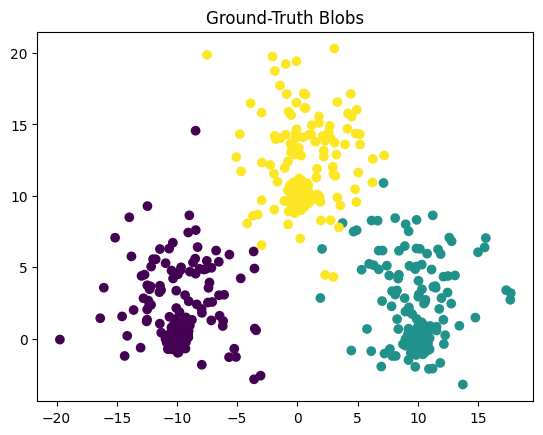

In [810]:
centers = [[-10.0, 0.0], [-10.0, 3.0], [10.0, 0.0], [10.0, 3.0], [0.0, 10.0], [0.0, 13.0]]
clusters_std = [0.5, 3.0, 0.5, 3.0, 0.5, 3.0]

n_per_comp = [100, 100, 100, 100, 100, 100]

X, raw_labels = make_blobs(
    n_samples = n_per_comp,
    centers = centers,
    cluster_std = clusters_std,
    random_state = 42
)

true_labels = raw_labels // 2

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show()

Noisy dataset

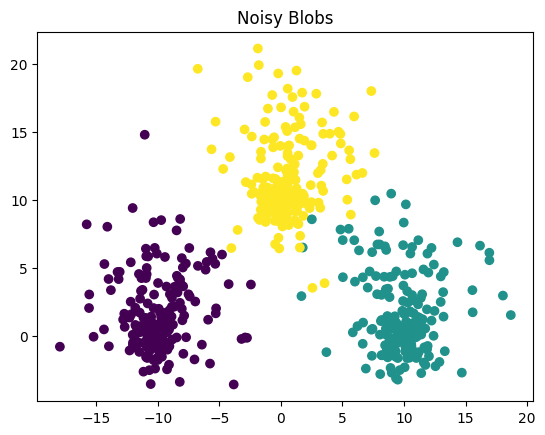

In [811]:
std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

### Define the map G(x) = ||x^2|| (squared norm)
- This reduces each d dimensional point into a single scalar, which represents the squared distance from the origin for each point (where the origin is (0, 0, ... , 0) depending on the dimension of our data)

In [ ]:
G_X_obs = np.sum(X_obs**2, axis=1) #Should I do this in a different notebook?????

### Making a grids for our data
- The first grid is for the points in the data domain while the second grid is for the points in the frequency domain

- The M variable is the number of gridpoints in the domain we are estimating the desnisty on
    - The reason we use 512 is because fast fourier transforms work best with power of 2 lengths, this is the closest powr of 2 to 400 which is the number of datapoints we have
        * To try in the future: Make it so it is adaptable to the amount of data points you use

- We use a buffer to add an added margin around the grid which helps prevent edge effects
    - This is to avoid underestimation of desnity near edges since the kernel measures the desnsity of a certain regio, we dont want it to "spill" out of the grid

- To form our grids we use linspace to create a regularly spaced grid over our interval

- t_grid represents the grid for our frequencies (in radians per unit), so we need our distance in the fft.freq function which turns our distance for our grid into 1/seperation and then we multiply by 2pi to turn them into radian values

In [813]:
x_size, M = len(X_obs), 2**9

buffer = 0.1 * (X_obs.max() - X_obs.min())

x_min = X_obs.min() - buffer
x_max = X_obs.max() + buffer

x_grid = np.linspace(x_min, x_max, M)

seperation = x_grid[1] - x_grid[0]

t_grid = 2 * np.pi * np.fft.fftfreq(M, d=seperation)

### Tricube kernel for compact support and smoothness
- Our parameter is t_scaled because we scale our data points in the frequency domain t by our threshold smoothing value h 

- The reason for our operation with inner where we make any values > 1 or < -1 equal to 0, since our interval is [-1:1], this is because we only wan tto keep the frequency components near 0. This is done because the low frequency component of our data represents the broad, smooth, structure of the data. While the high frequency components represents the noise

- To calculate h we minimize an apporximation of the AMISE (Asymptotic Mean Integrated Squared Error), 
    * Since we know are noise is gaussian we use this specific formula, but is there a way to construct a formula that can adapt to any noise?
        * We would want to do this because the higher then noise the more we would want to smooth 
            * I have found a way to adapt it to the noise simply by mutliplying our noise with the gaussian function

- phi_K represents the fourier transform of the kernel function, we want this because when we convolve a kernel with data in real space, it becomes multiplication in the frequency domain, hence we will convolve the kernel with our density estimate to smooth it out by an amount depending on the noise

- The point of the kernel in the algorithm is to stabilize the estimate if there are any wild oscillations or poor estimates

- The h value is a modification of the classic gaussian noise bandwidth with noise integration
    - This is added because h should be larger when the noise is large (more smoothing), and should be smaller when the noise is small (less smoothing)
    - Another option could be using a local bandwidth h instead of a global bandwidth h

In [ ]:
def tricube_kernel_ft(t_scaled):
    u = t_scaled
    inner = (1 - np.abs(u)**3)**3
    inner[np.abs(u) > 1] = 0.0
    return (70 / 81) * inner

h = std * (np.log(x_size) / x_size)**(1 / 5)

phi_K = tricube_kernel_ft(t_grid * h)

0.40324042603508176


### Computing the empirical characteristic form of our oberved/noisy data and noise

- Computing the empirical characteritisc form of our observed/noisy data means calculating the expected complex exponential e^itX over our data. This brings our data to othe frequency domain and serves as proxy for the fourier transform of the observed density. phi_X = 1/n sigma(n, 1) e^itX, which is not exactly fast fourier transform 

- Computing the fourier transform of the noise involves evaluating the known analytic expression for the characteristic function of the noise. For example, if the noise is Gaussian with variance sigma^2 then then the characteritsic function would be phi_U = e^(-0.5)*sigma^2*t^2. This ste is crucial because in the frequency domain the convolution becomes a multiplication, and deconvolution becomes division. That's why we work in the frequency domain -> To divide out the noise of the observed data 

- The line for phi_U_safe is basically just replacing phi_U with a very small value if it is too small to avoid division by zero

In [815]:
phi_X = np.mean(np.exp(1j * np.outer(t_grid, X_obs)), axis=1)

phi_U = np.exp(-0.5 * (std ** 2) * (t_grid ** 2))

eps = 1e-6
phi_U_safe = np.where(np.abs(phi_U) < eps, eps, phi_U)

### Now that we have both the observed data and the noise in the frequency domain we can "deconvolve" our observed data by dividing the observed data by the noise all in the frequency domain. But our estimate could still be noisy, so we smooth it out by multiplying our phi_K by the fourier transform of the kernel, essentially applying. alow pass filter

In [816]:
phi_Y = phi_X / phi_U_safe

smoothed_phi_Y = phi_Y * phi_K

### We can now invert our data from the frequency domain to the data domain

- The shifting done rearranges the array to zero so th efrequency is at the start. This is necessary because np.fft.ifft assumes zero frequency is at the start, then np.fft.ifft computes the inverse fourier transform of the, turning the frequency domain data into data domain data. Which is our estimate desnsity 

- np.real is necessary because it takes only the real part of the data since there are imaginary parts in the frequency domain data

- len(t_grid) / (2* np.pi) rescales the output to our liking

- np.trapz(f_hat, x_grid) computes the integral of f_hat over the grid x_grid using the trapezoidal rule, which normalizes the density (ensures the total probaability is 1)

In [817]:
f_hat = np.real(np.fft.ifft(np.fft.ifftshift(smoothed_phi_Y))) * M / (2* np.pi)
f_hat /= np.trapz(f_hat, x_grid)

/var/folders/v8/5w6w3d096r9c_nw0xsjrrfbm0000gp/T/ipykernel_60095/2505528907.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f_hat /= np.trapz(f_hat, x_grid)


### Interpolation of f_hat grid 
- Since f_hat gives us the deconvolved density only at the fixed grid points in t_grid, we don't know the exact values of the density att our actual data points
- To estimate the desnsity at these non-grid locations, we interpolate, which fills the gap between grid points by estimating values in between

In [818]:
interp_func = interp1d(x_grid, f_hat, kind='linear', fill_value="extrapolate")

density_X_obs = interp_func(X_obs[:,0])

### Computation of mutual reachability
- Now that we have a density estimate (f_vals) we can compute our core distances then mutual reachability  
- First we construct a k-nearest neighbours finder onnour observed data, which returns for each point the 5 nearest neighbours
- Then we calculate the core distances by taking the inverse of our density estimate and we add a small number to make sure we are not dividing by zero. The way this works is when the estimated density is large it means the core distance is small, however when the estimated desnity is small the core distance is large 
- The next step is computing the pairwise euclidian distance matrix of shape (n, n) where n = len(X_obs), this is done with the d_obs variable, (distance between observed data points)
- Then we reshape our core distances into 2 1-d arrays, so our mutual reachability can be computed 
- To compute our mutual reachbility we take the maximum of the ocre distance of the points i and j for the (i, j) mutual reachability with the fall back values of our observed data. Basically, we take the most sparse region as our estimate for mutual reachability
- We then comapre our results with vanilla hdbscan using ARI

In [819]:
from fast_hdbscan.boruvka import sample_weight_core_distance

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_obs)

core_dist_unc = 1.0 / (density_X_obs + 1e-8)

d_obs = np.linalg.norm(
    X_obs[:, None, :] - X_obs[None, :, :],
    axis=2
)

cd_i = core_dist_unc[:, None]   
cd_j = core_dist_unc[None, :]

mutual = np.maximum(np.maximum(cd_i, cd_j), d_obs)

clusterer = HDBSCAN(
    metric='precomputed',
    min_samples=k,
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(mutual)

ari = adjusted_rand_score(true_labels, pred_labels)
print("ARI (uncertainty-aware, variant 4):", ari)

ARI (uncertainty-aware, variant 4): 0.5904461555633574


### Using the density estimate for min cluster size 

In [820]:
k = 5
nbrs = NearestNeighbors(n_neighbors=50).fit(X_obs)

distances, indices = nbrs.kneighbors(X_obs)

samples_weight = density_X_obs

core_dist_unc_2 = sample_weight_core_distance(
    distances=distances,
    neighbors=indices,
    sample_weights=samples_weight,
    min_samples=k
)

d_obs_2 = np.linalg.norm(
    X_obs[:, None, :] - X_obs[None, :, :],
    axis=2
)

cd_i_2 = core_dist_unc[:, None]   
cd_j_2 = core_dist_unc[None, :]

mutual_2 = np.maximum(np.maximum(cd_i_2, cd_j_2), d_obs_2)

clusterer_2 = HDBSCAN(
    metric='precomputed',
    min_samples=k,
    min_cluster_size=k
)

pred_labels_2 = clusterer.fit_predict(mutual_2)
ari_2 = adjusted_rand_score(true_labels, pred_labels_2)
print("ARI (uncertainty-aware, variant 5):", ari_2)

ARI (uncertainty-aware, variant 5): 0.5904461555633574


### Problems:
- When the clusters are close to eachother or have noise larger than 1.0 we get nan values since we have a division by zero which originates from....
    - Solved by accounting for noise in threshold (smoothing) value 
- 

### To say:

- If we are not done by end of august I am working in Toronto for the fall and want to still work on this or if we are done this work on another project on my free time, after work everyday or something. 

- The deconvolution method is performing around the same ARI as HDBSCAN if not worse (so far)

### Questions:

- Should we try and improve deconvolution as much as possible before implementing the change of variable operation yuou mentioned?
    - :

- How can we improve our normal deconvolution KDE, I have tried a few different global thresholds, but other than that I have not made any significant optimizations. What would you suggest, maybe using a local threshold (h) 
    - :

- How to organise repo from now on, so far we have been only using Jupyter notebooks for the trials. Do you want to make it modular even while we are trying to outperform HDBSCAN? Also the fast_hdbscan repo is more functional programming, do you think it would be better to write functional or object oriented code?
    - : 

- What are we looking for in terms of performance, I know we are looking to outperform vanilla HDBSCAN, but what is a range of ARI that we are looking for, for it to be useful?
    - :

- Would you like us to take notes in Overleaf, or is it just for the final project??
    - :

- Will the compression of our observations (aka change of variable im pretty sure) improve the performance of our algirthm, or is it solely for optimization purposes? And is it somethig we want to adapt fully, hence edititng this notebook to do it? 
    - : 

- Could you explain further the k-nearest neighbours graph you mentioned at the end of the email?
    - :

### Notes from first meeting about this with professor smith:

Fourier transform of a gaussian is a gaussian 

Rreal orld application -> document retreival 

Interpoltion is just filling in the lines

That is step 1 -> finish the fourier divier/multiplier then do some interpolation if necesssaryy

arxiv for math and stuff

Step 2:
- Try to use in 1 dim hdbscn whith 2 gaussians (with a risen valley)
    - You will onlt have the didstanc between points and not the actual position of the points
    - min_cluster size have a theshold that stops sparseclusters (low density) not let the clusrr dm h
    - edit the min_clustrrin the algorithm 
    - (might get reanamed in the code)
    - sklearn signle linkage tree
    - Replace the if statement in min_cluster size where you replafe the sum of 1's by the density of a point
    - the density quals 1/mutual reachiability
- Test as much as you can with the, 
- Look into fourier transforms with graphs 
- Division. by 0 issue 